# Final Python Notebook 3: Loan Approval Status ensemble classifier with its base learners’ performances and Maximum Loan Amount Regression Decision Trees, with their graphical representation and performances.   

**Author:** K.Bhagya Anuhasini Silva

**Declaration:**

I hereby declare that all the codes included in this notebook were learned and developed during **Seminar Sessions 5, 6, and 7**. The implementation and compilation of these codes are entirely my own work. I also confirm that this work has not been used in any other coursework or submitted for any other academic work previously.

**Code peer Review:**

Reviewer: None
Date: 25/03/2026

Test Cases:

*   Use Hyperparameter Tuning
*   Calculate Client Attributes












In [ ]:
# Probability-Based Voting Ensemble Classifier
# Load prepared regression dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/Evaluated_classification_dataset_prepared.csv')


In [ ]:
# define categorical data and numeric data
categorical_vars = [
    'home_ownership',
    'loan_intent',
    'payment_default_on_file'
]

numeric_vars = [
    'age',
    'income',
    'emplyment_length',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'credit_history_length'
]

print("Categorical variables:", categorical_vars)
print("Numeric variables:", numeric_vars)

Categorical variables: ['home_ownership', 'loan_intent', 'payment_default_on_file']
Numeric variables: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']


In [ ]:
# convert categorical data into numerical
df_encoded = pd.get_dummies(
    df,
    columns=categorical_vars,
    drop_first=True
)

print("Dataset shape after encoding:", df_encoded.shape)
df_encoded.head()

Dataset shape after encoding: (58645, 17)


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,home_ownership_1,home_ownership_2,home_ownership_3,loan_intent_1,loan_intent_2,loan_intent_3,loan_intent_4,loan_intent_5,payment_default_on_file_1
0,-1.085843,-1.372135,-1.174419,1.039305,-1.214715,-0.427932,-0.450108,0,False,True,False,True,False,False,False,False,False
1,-1.085843,-1.340499,-0.675037,2.836651,2.006922,0.335502,-0.698298,0,False,True,False,True,False,False,False,False,True
2,-0.754326,-1.435409,0.074037,3.735324,0.573985,1.644245,-0.698298,0,False,False,True,False,False,True,False,False,False
3,2.063567,3.109818,-0.425346,4.633996,-0.882010,0.335502,1.287227,0,False,False,True,True,False,False,False,False,False
4,2.063567,0.684242,-0.425346,4.633996,0.573985,2.516741,2.031798,0,False,False,False,False,True,False,False,False,False


In [ ]:
# print categorical and numeric data with their datatypes
categorical_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
Index([], dtype='object')

Numeric columns:
Index(['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length',
       'loan_approval_status'],
      dtype='object')


In [ ]:
# convert categorical data into numerical
data_frame_encoded = pd.get_dummies(
    df,
    columns=['home_ownership', 'loan_intent', 'payment_default_on_file'],
    drop_first=True
)

In [ ]:
# print encoded data datatypes
print(data_frame_encoded.dtypes.value_counts())

bool       9
float64    7
int64      1
Name: count, dtype: int64


In [ ]:
# define x and y
X = data_frame_encoded.drop('loan_approval_status', axis=1)
y = data_frame_encoded['loan_approval_status']

In [ ]:
# search for NaN rows of y

print(f"NaN count in y: {y.isna().sum()}")
print(f"Total rows: {len(y)}")

NaN count in y: 0
Total rows: 58645


In [ ]:
# keep only the rows where y is NOT NaN

mask = ~y.isna()
X = X[mask]
y = y[mask]

In [ ]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (46916, 16)
Test shape: (11729, 16)


In [ ]:
# print x datatypes
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [ ]:
#Fit your models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


In [ ]:
#Probability-Based Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn)
    ],
    voting='soft'  # probability-based voting
)

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

In [ ]:
# Model Evaluation Outputs
# Logistic Regression
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix (LR):\n", confusion_matrix(y_test, y_pred_lr))
print("AUC-ROC (LR):", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729

Confusion Matrix (LR):
 [[9798  261]
 [ 959  711]]
AUC-ROC (LR): 0.8882584368989429


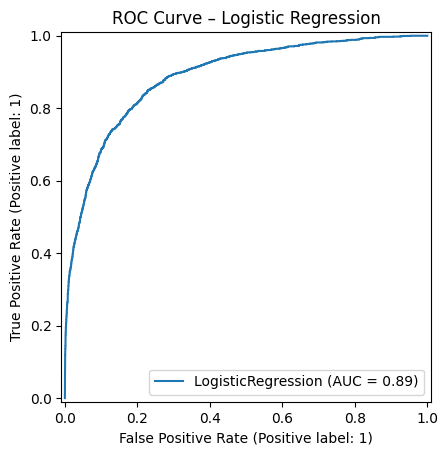

In [ ]:
# ROC curve - LR
RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("ROC Curve – Logistic Regression")
plt.show()

In [ ]:
#K-Nearest Neighbours
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("AUC-ROC (KNN):", roc_auc_score(y_test, y_prob_knn))

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.81      0.56      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.77      0.81     11729
weighted avg       0.91      0.92      0.91     11729

Confusion Matrix (KNN):
 [[9842  217]
 [ 741  929]]
AUC-ROC (KNN): 0.8671463812607413


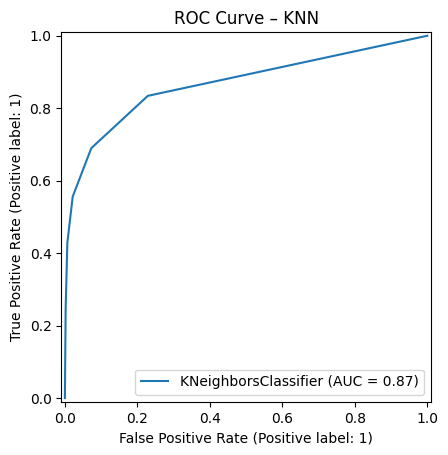

In [ ]:
# ROC curve - KNN
RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title("ROC Curve – KNN")
plt.show()

In [ ]:
# Voting Ensemble Classifier
y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

print("Voting Ensemble Classification Report:\n")
print(classification_report(y_test, y_pred_ens))

print("Confusion Matrix (Ensemble):\n", confusion_matrix(y_test, y_pred_ens))
print("AUC-ROC (Ensemble):", roc_auc_score(y_test, y_prob_ens))


Voting Ensemble Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10059
           1       0.83      0.51      0.63      1670

    accuracy                           0.92     11729
   macro avg       0.88      0.75      0.79     11729
weighted avg       0.91      0.92      0.91     11729

Confusion Matrix (Ensemble):
 [[9888  171]
 [ 815  855]]
AUC-ROC (Ensemble): 0.9095571457740649


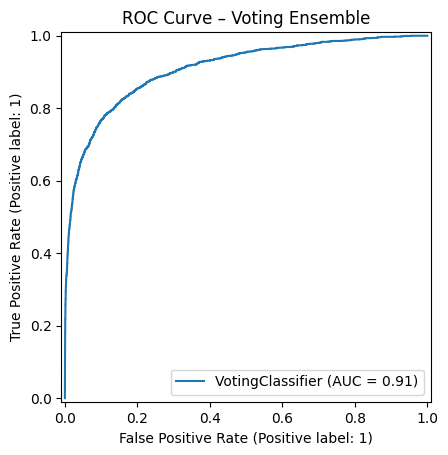

In [ ]:
# ROC curve - voting ensemble
RocCurveDisplay.from_estimator(ensemble, X_test, y_test)
plt.title("ROC Curve – Voting Ensemble")
plt.show()

In [ ]:
# save tuned classification dataset
df.to_csv('/content/Tuned_Evaluated_classification_dataset_prepared.csv', index=False)

In [ ]:
#Load prepared regression dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Load dataset
df = pd.read_csv('/content/Regression_dataset_prepared.csv')

# Target
target = 'max_allowed_loan'

# Split X and y
X = df.drop(columns=[target])
y = df[target]

In [ ]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index(['home_ownership', 'loan_intent', 'payment_default_on_file'], dtype='object')


In [ ]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Any object columns left?")
print(X_encoded.select_dtypes(include='object').columns)

Any object columns left?
Index([], dtype='object')


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(46916, 16)


In [ ]:
# DT1 regressor
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_train, y_train)

print("DT-1 trained successfully")

DT-1 trained successfully


In [ ]:
# DT2 regressor
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2.fit(X_train, y_train)

print("DT-2 trained successfully")

DT-2 trained successfully


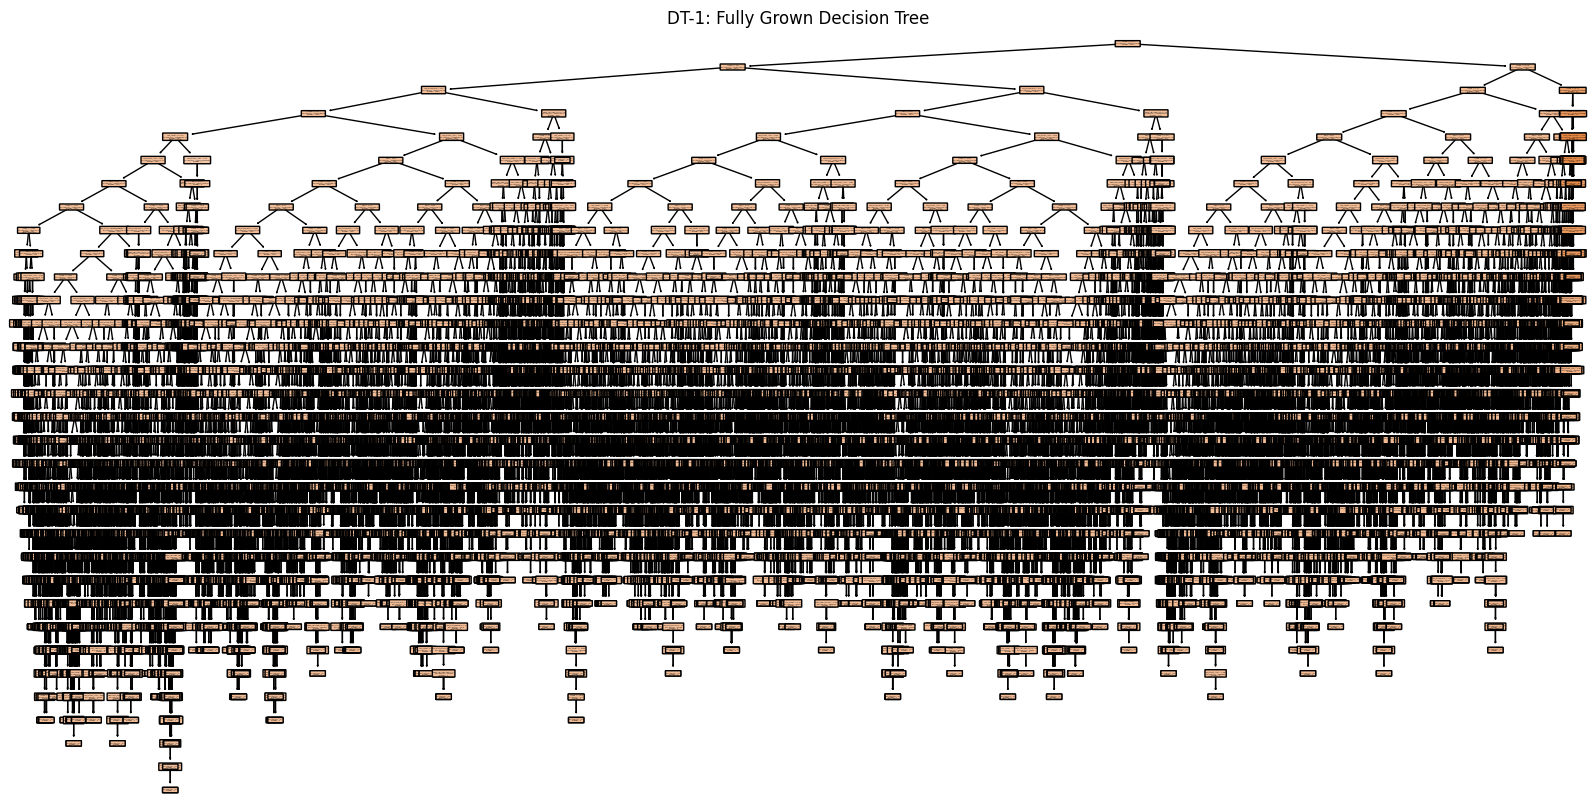

In [ ]:
#Task (2c) – Visualise DT-1 and DT-2
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# DT-1 visualization
plt.figure(figsize=(20,10))
plot_tree(
    dt1,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)
plt.title("DT-1: Fully Grown Decision Tree")
plt.savefig("DT1.png", dpi=300, bbox_inches="tight")
plt.show()

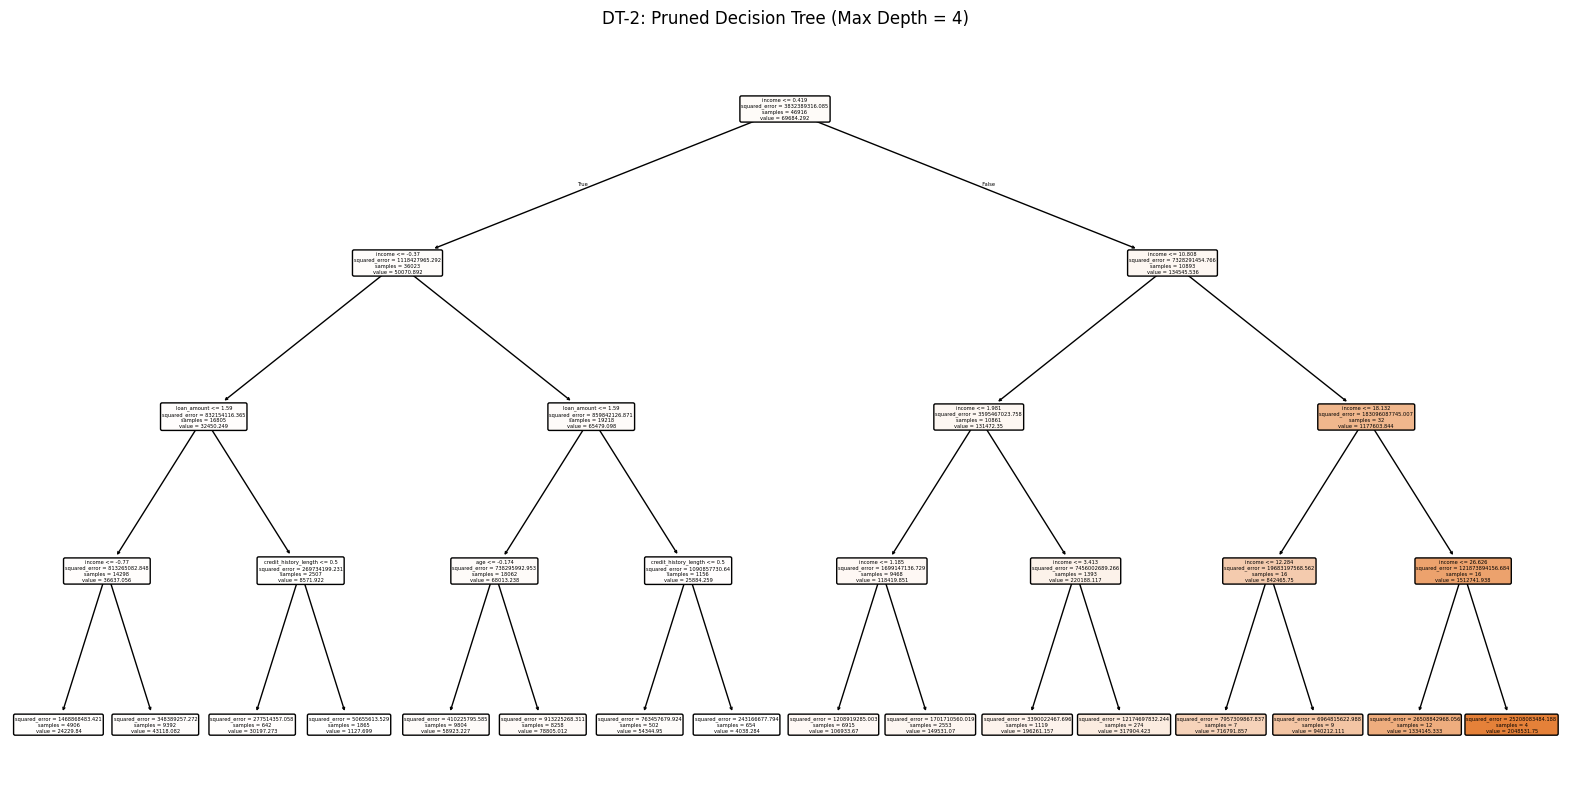

In [ ]:
# DT-2 visualization
plt.figure(figsize=(20,10))
plot_tree(
    dt2,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.title("DT-2: Pruned Decision Tree (Max Depth = 4)")
plt.savefig("DT2.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Task (3a) – Evaluation Metrics (CODE + JUSTIFICATION)
# Predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_dt1 = dt1.predict(X_test)
y_pred_dt2 = dt2.predict(X_test)

In [ ]:
#Calculate metrics
metrics = pd.DataFrame({
    'Model': ['DT-1 Fully Grown', 'DT-2 Pruned'],
    'MSE': [
        mean_squared_error(y_test, y_pred_dt1),
        mean_squared_error(y_test, y_pred_dt2)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_dt1),
        mean_absolute_error(y_test, y_pred_dt2)
    ],
    'R2': [
        r2_score(y_test, y_pred_dt1),
        r2_score(y_test, y_pred_dt2)
    ]
})

print(metrics)

              Model           MSE           MAE        R2
0  DT-1 Fully Grown  7.092678e+08   8043.846961  0.810148
1       DT-2 Pruned  9.012502e+08  17918.346974  0.758759


In [ ]:
# metrics for the DT 1 and 2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_dt1 = dt1.predict(X_test)
y_pred_dt2 = dt2.predict(X_test)

print(" - DT-1 (Fully Grown) -")
print("MSE:", mean_squared_error(y_test, y_pred_dt1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt1)))
print("MAE:", mean_absolute_error(y_test, y_pred_dt1))
print("R2:", r2_score(y_test, y_pred_dt1))

print("\n - DT-2 (Pruned, Max Depth=4) -")
print("MSE:", mean_squared_error(y_test, y_pred_dt2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt2)))
print("MAE:", mean_absolute_error(y_test, y_pred_dt2))
print("R2:", r2_score(y_test, y_pred_dt2))

 - DT-1 (Fully Grown) -
MSE: 709267765.8005798
RMSE: 26632.08151460527
MAE: 8043.846960525194
R2: 0.8101478431065661

 - DT-2 (Pruned, Max Depth=4) -
MSE: 901250180.5019467
RMSE: 30020.82911083481
MAE: 17918.34697360816
R2: 0.7587592459164435


In [ ]:
# Client 60256 attributes
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'emplyment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23,
    'loan_income_ratio': 0.10,
    'credit_history_length': 35,
    'home_ownership_RENT': 1,
    'home_ownership_OWN': 0,
    'loan_intent_MEDICAL': 1,
    'payment_default_on_file_Y': 0
}])

# Align columns with training data
client_60256 = client_60256.reindex(columns=X_encoded.columns, fill_value=0)

# Predict using DT-2 (best model)
predicted_loan = dt2.predict(client_60256)
print("Predicted Maximum Loan Amount for Client 60256: £", round(predicted_loan[0], 2))

# Show decision path
node_indicator = dt2.decision_path(client_60256)
print("\nNumber of nodes visited:", node_indicator.nnz)

Predicted Maximum Loan Amount for Client 60256: £ 2048531.75

Number of nodes visited: 5


In [ ]:
# save evaluated regression model
df.to_csv('/content/Evaluated_Regression_dataset_prepared.csv', index=False)